In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Exercise 1
Let $A$ denote an array consisting of random integers between $0$ and $10$. Count the number of times $A$ has a sequence of repeated entries.

In [ ]:
A = np.random.uniform(low = 0, high = 10,size = (15,) )
A = np.array([1,2,3,3,3,4,5,6,7,7])

# SOLUTION 1
ctr = 0

for idx, el in np.ndenumerate(A):
    if idx == (A.size-1,):
        break
    if A[idx] == A[(f)]:
        ctr+=1
    
print(ctr)

# SOLUTION 2

ctr = 0
prev = A[0]
for el in np.nditer(A[1:]):
    if el == prev:
        ctr+=1
    prev = el
print(ctr)

3


# Exercise 2

Write a function `transform_array` which takes as input a 2-dimensional array $M$ and returns a new array $N$ of the same shape as $M$ such that $n$ in $N$ is given by the following formula: $n=m$ if $m$ is odd, $n=2*m+1$ if $m$ is even.

In [ ]:
# CODE HERE
# SOLUTION 1
def transform_array(M):
    N = np.zeros_like(M)
    for idx, el in np.nedenumerate(M):
        if el % 2 == 0 :
            N[idx] = 2*el +1
        else:
            N[idx] = el
    return N
# Solution 2
def transform_array(M):
    N = np.zeros_like(M)
    N[M % 2 == 0] = 2*M[M % 2 == 0] + 1
    N[M % 2 != 0] = M[M % 2 != 0]
    return N


# Exercise 3

Plot the motion of the following system using Euler's method:

Recall Newton's law of gravity,
\begin{align*}
    \frac{d^2r}{dr^2}=\frac{1}{m}\frac{Gm_1m_2}{r^2}
\end{align*}
where $G = 6.674\times 10^{-11}$. 

We will study the motion of a mass $1$ ball flying as a projectile on Earth where the mass of the earth is $5.9722\times 10^{24}$.

The radius of the earth is $6,371,000$.

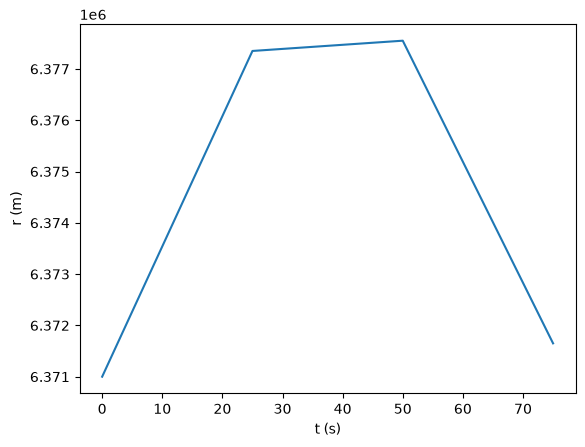

In [24]:
import numpy as np
import matplotlib.pyplot as plt

h = 25
t = np.arange(0, 100, h)

r_earth = 6_371_000
G = 6.674e-11
m_earth = 5.9722e24

r = np.zeros_like(t)
theta = np.zeros_like(t)
vr = np.zeros_like(t)

r[0] = r_earth
vr[0] = 500    # radial launch speed, m/s
vt0 = 10                 # tangential speed, m/s

for i in range(1, len(t)):
    if r[i-1] >= r_earth:
        a = -G*m_earth/r[i-1]**2 
        vr[i] = vr[i-1] + h*a
        r[i]  = r[i-1] + h*vr[i]                   
        theta[i] = theta[i-1]
    else:
        r[i] = r[i-1]
        theta[i] = theta[i-1]

plt.plot(t, r)
plt.xlabel("t (s)")
plt.ylabel("r (m)")
plt.show()

# Exercise 4

A positive integer $n$ is called *happy* if when we repeatedly replace $n$ by the sum of the squares of its digits, it eventually equals $1$, otherwise it is called unhappy. Write a function `happy(n)` which determines if a number is *happy*. Your function should have a parameter that controls the maximum number of iterations of this procedure.

In [ ]:
# CODE HERE

# SOLUTION 1 - Recursion
def happy(n, current_iter =0, max_iter = 1_000):
    sum_squares_digits = 0
    ns = str(n)
    for digit in ns:
        sum_squares_digits += int(digit)**2
    if  current_iter > max_iter:
        return False
    if sum_squares_digits == 1:
        return True
    else:
        return happy(sum_squares_digits, current_iter = current_iter + 1)

# SOLUTION 2 - loops

def happy(n, max_iter = 1_000):
    iter = 0
    while iter <= max_iter:
        sum_squares_digits = 0
        ns = str(n)
        for digit in ns:
            sum_squares_digits += int(digit)**2
        if sum_squares_digits == 1:
            return True
        iter += 1
    return False
        
    
    

# Exercise 5

Implement a class for the integers modulo $3$ in Python

In [ ]:
class Mod3:
    def __init__(self,int):
        self.val = int % 3
    def __str__(self):
        return f"{self.val} mod 3"
    def __eq__(self,other):
        return self.val == other.val
    def __add__(self,other):
        return f"{(self.val + other.val) % 3} mod 3"
    __radd__ = __add__
    def __mul__(self,other):
        return (self.val*other.val) % 3
    __rmul__ = __mul__
    def __pow__(self,n):
        if n == 0:
            return 1
        else:
            return self.val*self.__pow__(n-1)

In [29]:
a = Mod3(8)
b = Mod3(4)

print(a)
print(b)
print(a + b)

2 mod 3
1 mod 3
0
